<a href="https://colab.research.google.com/github/reshmabano2812-ai/StockPricePredictor/blob/main/STOCK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.download('World-Stock-Prices-Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

LOADING DATA....

In [ ]:
import pandas as pd
df=pd.read_csv('World-Stock-Prices-Dataset.csv')
df['Date']=pd.to_datetime(df['Date'],utc=True).dt.date
df.set_index('Date',inplace=True)
df=df.drop(columns=['Brand_Name','Ticker','Industry_Tag','Country','Dividends','Stock Splits','Capital Gains'])
df

,Open,High,Low,Close,Volume
Date,,,,,
2025-07-03,6.630000,6.740000,6.615000,6.640000,4209664.0
2025-07-03,106.750000,108.370003,106.330101,107.339996,560190.0
2025-07-03,122.629997,123.050003,121.550003,121.930000,36600.0
2025-07-03,221.705002,224.009995,221.360001,223.410004,29295154.0
2025-07-03,212.145004,214.649994,211.810104,213.550003,34697317.0
...,...,...,...,...,...
2000-01-03,38.147537,38.255972,35.935457,37.496925,53076000.0
2000-01-03,25.215814,25.330655,24.690826,24.772856,2173400.0
2000-01-03,72.313085,72.405794,71.756831,72.034958,21200.0


PREPARING DATA....

In [ ]:
def prepare_data(df,forecastDays=30):
     df=df[['Close']].copy()
     df['Prediction']=df[['Close']].shift(-forecastDays)
     X= np.array(df.drop('Prediction',axis=1))[:-forecastDays]
     y=np.array(df['Prediction'])[:-forecastDays]
     return X,y,df

TRAINING AND PREDICTING DATA

In [ ]:
def train_and_predict(X,y,df,forecastDays=30):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
    model=LinearRegression()
    model.fit(X_train,y_train)
    prediction=model.predict(X_test)
    mse=mean_squared_error(y_test, prediction)
    r2=r2_score(y_test,prediction)
    print('Model Evaluation:')
    print(f'MSE:{mse:.2f}')
    print(f'R2: {r2:.4f}')
    X_future=np.array(df.drop(['Prediction'],axis=1))[-forecastDays:]
    futurePredictions=model.predict(X_future)
    return futurePredictions,model

PLOTTING THE DATA ...

In [ ]:
def plotPrediction(df,future_days,futurePredictions):
    df_future=df.copy()
    last_date=df.index[-1]
    future_dates=pd.date_range(last_date + pd.Timedelta(days=1),periods=future_days)
    plt.figure(figsize=(12,6))
    plt.plot(df['Close'],label='Historical Close Price')
    plt.plot(future_dates,futurePredictions,label='Predicted Future Price',linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Price' )
    plt.title('Stock Price Distribution ')
    plt.legend()
    plt.show()

In [ ]:
forecastDays=300
stockData=df
print(stockData)

                 Close  Prediction
Date                              
2025-07-03    6.640000  569.239990
2025-07-03  107.339996  294.079987
2025-07-03  121.930000  328.130005
2025-07-03  223.410004  379.309998
2025-07-03  213.550003   61.369999
...                ...         ...
2000-01-03   37.496925         NaN
2000-01-03   24.772856         NaN
2000-01-03   72.034958         NaN
2000-01-03    7.168196         NaN
2000-01-03    5.482471         NaN

[310122 rows x 2 columns]


FINAL CALL ...

Model Evaluation:
MSE:18922.07
R2: 0.0331


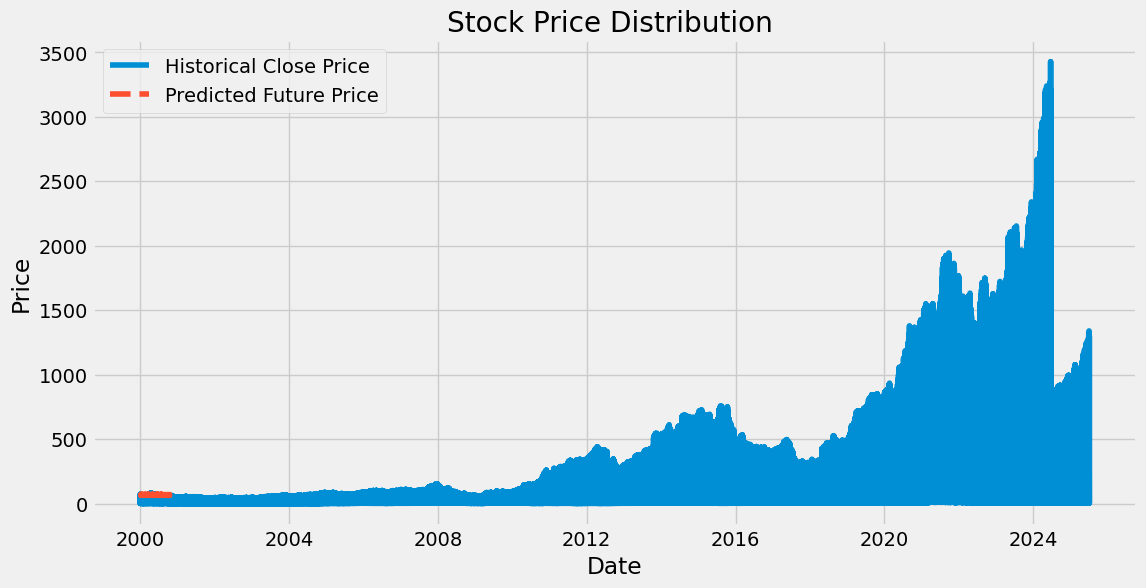

Future Price Prediction
[63.1740939  63.61981377 65.44196398 63.89961151 67.64459273 65.19646866
 66.56357322 63.51288494 66.88803782 67.72966503 63.89028726 64.41598928
 74.11198415 63.70326581 69.45276357 69.94803335 64.15374048 66.43780456
 65.87884827 63.70394363 64.71210749 63.64446896 68.75863205 65.80749468
 67.16553589 63.18659679 68.86884071 68.38299938 65.33804968 68.55181223
 68.47580493 68.7608333  63.74043483 69.30948501 66.41491224 69.57455883
 63.48172867 66.19785151 67.64459273 64.20516415 65.19239677 67.57832891
 65.3612     66.80104812 63.8797411  67.13215528 67.20812345 63.91179692
 74.07168441 64.42409194 64.77043213 66.46317371 65.73588806 63.16149424
 63.67154944 65.85023229 63.59916772 63.18098919 68.75139159 69.69106551
 67.47009833 63.71623014 67.63318487 67.03776959 63.7173779  63.85289959
 63.16882347 66.84280133 65.3237727  66.35391446 64.76395305 68.95321729
 65.74937498 67.51149307 63.90926952 63.69087621 65.35396252 64.41868995
 74.28928832 65.81889093 69

In [ ]:
X,y,df=prepare_data(stockData, forecastDays)
futurePredictions,model = train_and_predict(X,y,df, forecastDays)
plotPrediction(df, forecastDays, futurePredictions)
print("Future Price Prediction")
print(futurePredictions)